# Cholesterol Value Predictor (Traditional Machine Learning) - original dataset

### 1) Import Libraries

In [3]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/heartdisease_dataset"

#----- Tools, visualizers -----
from utils import *
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

#----- Preprocessing -----
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

#----- Models -----
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso,\
      ElasticNet, RANSACRegressor, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,\
      AdaBoostRegressor, ExtraTreesRegressor

#----- Variables -----
RANDOM_STATE = 42



### 2) Load Data

In [4]:
# Load train set
#---------------
data = pd.read_csv(DATA_DIR / "train_set.csv")
test = pd.read_csv(DATA_DIR / "test_set.csv")

data.shape, test.shape

((780, 12), (138, 12))

### 3) Drop rows with Cholesterol == 0

In [5]:
# Apply dropping operation on both data & test
data_chole_filtered = drop_invalid_cholesterol(data)
test_chole_filtered = drop_invalid_cholesterol(test)

# Make sure it's done as expected
zero_count_data = len(data_chole_filtered[data_chole_filtered['Cholesterol'] == 0].count(1))
zero_count_test = len(test_chole_filtered[test_chole_filtered['Cholesterol'] == 0].count(1))

print(f"Rows with cholesterol == 0 were dropped")
print(f"""Count of zeros after dropping:\ndata: {zero_count_data} --> new shape: {data_chole_filtered.shape}
test: {zero_count_test} --> new shape: {test_chole_filtered.shape}""")


Rows with cholesterol == 0 were dropped
Count of zeros after dropping:
data: 0 --> new shape: (641, 12)
test: 0 --> new shape: (105, 12)


### 4) Define feature columns and target
- 1. **Target:** Cholesterol, **Drop** HeartDisease feature column
- 2. **Target:** Cholesterol, **Keep** HeartDisease feature column 
> The “with‑HD” version will be handled later by simply concatenating the HD column after preprocessing.

In [6]:
"""
Separate features and target for the regression task.

- Target: `Cholesterol`
- Features (screening scenario): all columns except `Cholesterol` and `HeartDisease`
- The `HeartDisease` label is intentionally excluded here; it will be added
  later as an optional extra feature for the diagnostic comparison.
"""

# -------------------------------------
# Cholesterol as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_CHOLE_TRAIN = data_chole_filtered.drop(columns=['Cholesterol']) # Features
y_chole_train = data_chole_filtered['Cholesterol'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_CHOLE_TEST = test_chole_filtered.drop(columns=['Cholesterol']) # Features
y_chole_test = test_chole_filtered['Cholesterol'] # Labels


# -------------------------------------
# oldpeak as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_OLDP_TRAIN = data.drop(columns=['Oldpeak']) # Features
y_oldp_train = data['Oldpeak'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_OLDP_TEST = test.drop(columns=['Oldpeak']) # Features
y_oldp_test = test['Oldpeak'] # Labels




print("----- DONE -----")



----- DONE -----


### 5) Derived feature (Core feature engineering)

> **Rate‑Pressure Product (RPP)** is a measure of the stress put on the cardiac
> muscle based on the number of times it needs to beat per minute (HR) and the
> arterial blood pressure that it is pumping against (SBP).  
> **Formula:** `RPP = MaxHR × RestingBP`

> **Age × MaxHR** – captures the interaction between a patient’s age and their
> maximum achieved heart rate. Older patients typically have a lower maximum
> heart rate; this feature lets the model learn whether deviations from that
> expectation are linked to the target.

> **Age × RestingBP** – resting blood pressure tends to increase with age.
> This interaction helps the model capture age‑dependent variations in blood
> pressure that may relate to cholesterol or exercise‑induced ST depression.

> **Age²** – a simple polynomial term that allows linear models to fit a
> curved (quadratic) relationship with age. Many physiological variables do
> not change linearly across the lifespan.

> **Stress Response (MaxHR – RestingBP)** – approximates the heart‑rate
> reserve or the dynamic range of the heart during exercise. A small
> difference may indicate poor cardiovascular fitness or chronotropic
> incompetence.

> **Age group (binned Age)** – age is discretised into four clinically
> meaningful bands (`<40`, `40‑50`, `50‑60`, `>60`). This allows the model
> to capture step‑wise changes that often appear in epidemiological data
> (e.g., sharply rising cardiovascular risk after 60) without assuming a
> smooth linear trend.

#### - Apply feature engineering

In [7]:

def add_engineered_features(X):
    """Add clinically motivated derived features. Returns a new DataFrame."""
    X = X.copy()
    # Interaction terms
    X['Age_MaxHR'] = X['Age'] * X['MaxHR']
    X['Age_RestingBP'] = X['Age'] * X['RestingBP']
    X['RPP'] = X['MaxHR'] * X['RestingBP']
    # Polynomial
    X['Age_squared'] = X['Age'] ** 2
    # Physiological indices
    X['Stress_Response'] = X['MaxHR'] - X['RestingBP']   # approximate heart rate reserve
    # Binning – Age group
    X['Age_group'] = pd.cut(X['Age'], bins=[0, 40, 50, 60, 100],
                            labels=['<40', '40-50', '50-60', '>60'])
    return X

# Apply to cholesterol train/test
X_CHOLE_TRAIN = add_engineered_features(X_CHOLE_TRAIN)
X_CHOLE_TEST  = add_engineered_features(X_CHOLE_TEST)

# Apply to Oldpeak train/test
X_OLDP_TRAIN = add_engineered_features(X_OLDP_TRAIN)
X_OLDP_TEST  = add_engineered_features(X_OLDP_TEST)

print("----- Feature Eng done -----")
print(f"Cholesterol train shape: {X_CHOLE_TRAIN.shape}\nOldpeak train shape: {X_OLDP_TRAIN.shape}")

----- Feature Eng done -----
Cholesterol train shape: (641, 17)
Oldpeak train shape: (780, 17)


In [7]:
# Take a look at cholesterol Train
X_CHOLE_TRAIN.head(10)

,Age,Sex,ChestPainType,RestingBP,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_MaxHR,Age_RestingBP,RPP,Age_squared,Stress_Response,Age_group
0,43,M,ASY,132,1,LVH,143,Y,0.1,Flat,1,6149,5676,18876,1849,11,40-50
1,68,M,NAP,118,0,Normal,151,N,1.0,Up,0,10268,8024,17818,4624,33,>60
2,57,M,ASY,132,0,Normal,168,Y,0.0,Up,0,9576,7524,22176,3249,36,50-60
3,60,M,ASY,130,0,LVH,132,Y,2.4,Flat,1,7920,7800,17160,3600,2,50-60
4,40,M,NAP,140,0,Normal,188,N,0.0,Up,0,7520,5600,26320,1600,48,<40
5,51,F,NAP,150,0,Normal,120,N,0.5,Up,0,6120,7650,18000,2601,-30,50-60
6,39,F,NAP,138,0,Normal,152,N,0.0,Flat,0,5928,5382,20976,1521,14,<40
7,42,M,ATA,120,0,Normal,150,N,0.0,Up,0,6300,5040,18000,1764,30,40-50
8,41,M,ATA,125,0,Normal,144,N,0.0,Up,0,5904,5125,18000,1681,19,40-50
9,65,F,NAP,155,0,Normal,148,N,0.8,Up,0,9620,10075,22940,4225,-7,>60


In [8]:
# Take a look at oldpeak Train
X_OLDP_TRAIN.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,ST_Slope,HeartDisease,Age_MaxHR,Age_RestingBP,RPP,Age_squared,Stress_Response,Age_group
0,43,M,ASY,132,247,1,LVH,143,Y,Flat,1,6149,5676,18876,1849,11,40-50
1,68,M,NAP,118,277,0,Normal,151,N,Up,0,10268,8024,17818,4624,33,>60
2,57,M,ASY,132,207,0,Normal,168,Y,Up,0,9576,7524,22176,3249,36,50-60
3,60,M,ASY,130,206,0,LVH,132,Y,Flat,1,7920,7800,17160,3600,2,50-60
4,50,F,ASY,160,0,1,Normal,110,N,Flat,1,5500,8000,17600,2500,-50,40-50
5,40,M,NAP,140,235,0,Normal,188,N,Up,0,7520,5600,26320,1600,48,<40
6,51,F,NAP,150,200,0,Normal,120,N,Up,0,6120,7650,18000,2601,-30,50-60
7,39,F,NAP,138,220,0,Normal,152,N,Flat,0,5928,5382,20976,1521,14,<40
8,42,M,ATA,120,196,0,Normal,150,N,Up,0,6300,5040,18000,1764,30,40-50
9,41,M,ATA,125,269,0,Normal,144,N,Up,0,5904,5125,18000,1681,19,40-50


#### -  A quick sanity check and EDA for new features

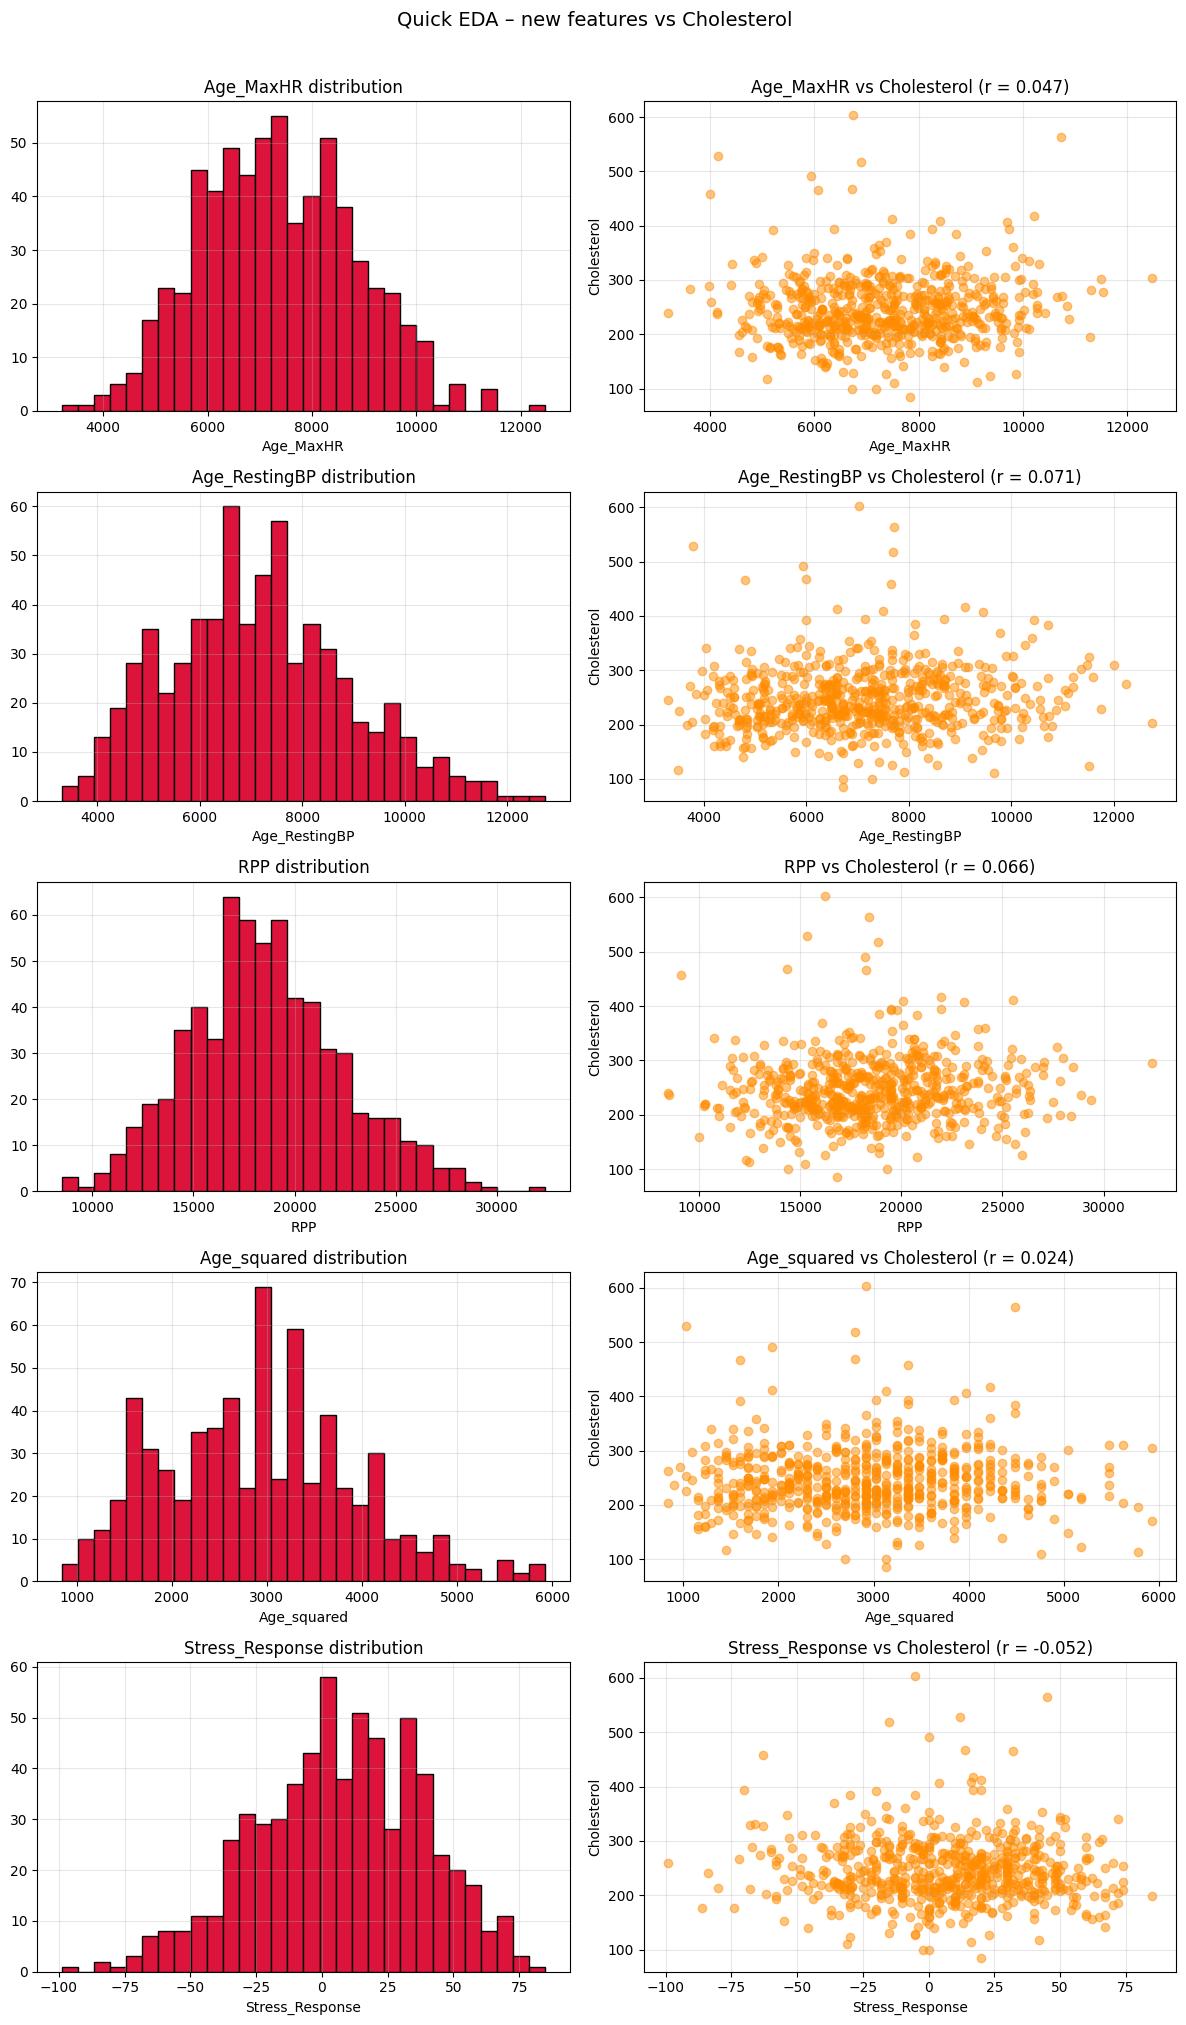

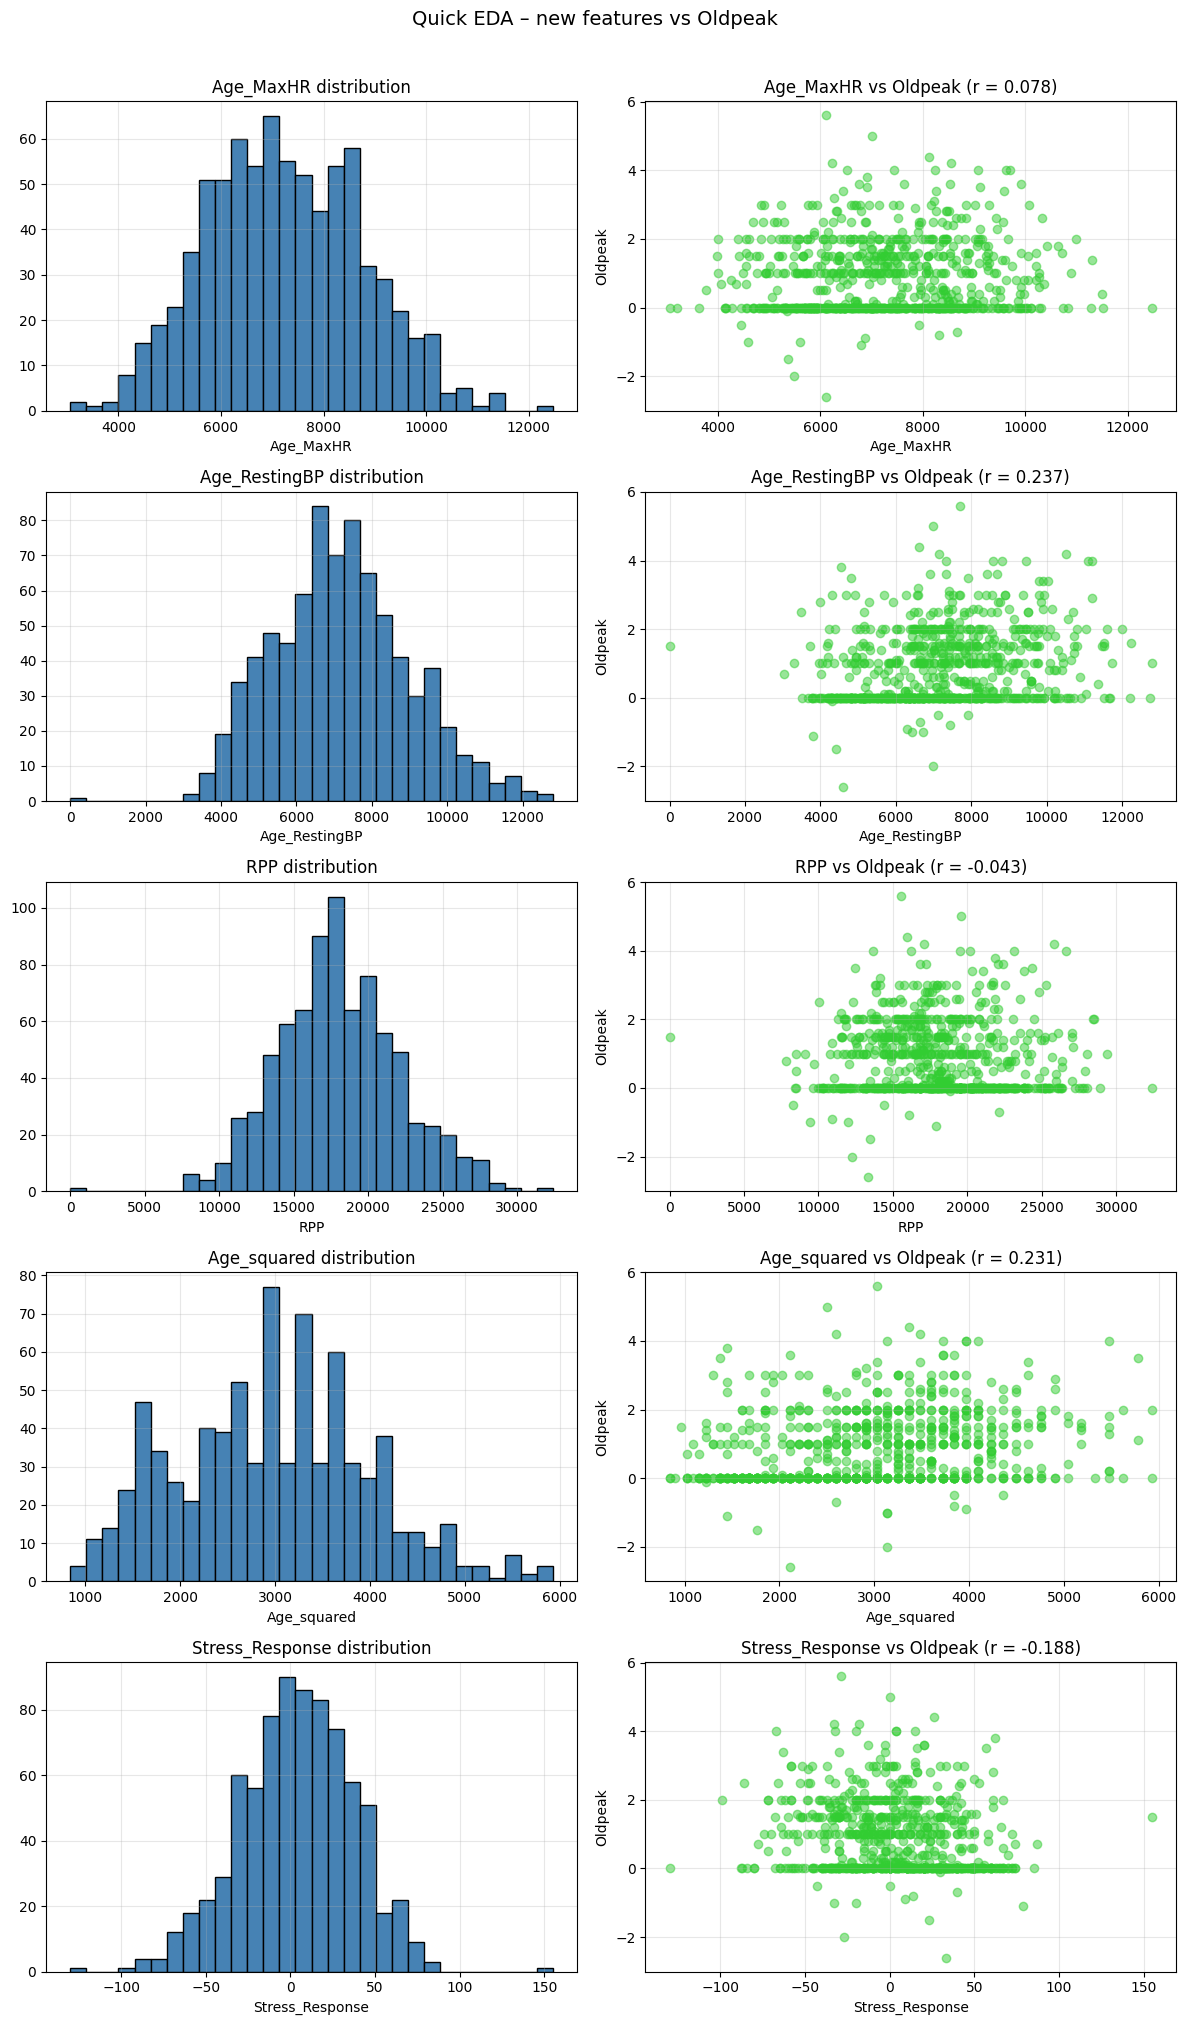

In [9]:
# Quick EDA on the numeric features
# ---------------------------------------------
def plot_features_eda(X, y, features, target_name, hist_c, scat_c, ncols=2):
    """
    For each feature in `features`, create a row with two subplots:
    histogram of the feature (left) and scatter vs target (right).
    """
    nrows = len(features)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    
    # Make sure axes is 2D even for a single row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feat in enumerate(features):
        r, _ = scipy.stats.pearsonr(X[feat], y)
        
        # Histogram
        axes[i, 0].hist(X[feat], bins=30, color=hist_c, edgecolor='k')
        axes[i, 0].set_title(f'{feat} distribution')
        axes[i, 0].set_xlabel(feat)
        axes[i, 0].grid(alpha=0.3)
        
        # Scatter
        axes[i, 1].scatter(X[feat], y, alpha=0.5, color=scat_c)
        axes[i, 1].set_title(f'{feat} vs {target_name} (r = {r:.3f})')
        axes[i, 1].set_xlabel(feat)
        axes[i, 1].set_ylabel(target_name)
        axes[i, 1].grid(alpha=0.3)
    
    plt.suptitle(f'Quick EDA – new features vs {target_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()



# Features to check
engineered_features = ['Age_MaxHR', 'Age_RestingBP', 'RPP', 'Age_squared', 'Stress_Response']

# Cholesterol
plot_features_eda(X_CHOLE_TRAIN, y_chole_train, engineered_features,
                  'Cholesterol', 'crimson', 'darkorange')

# Oldpeak
plot_features_eda(X_OLDP_TRAIN, y_oldp_train, engineered_features,
                  'Oldpeak', 'steelblue', 'limegreen')

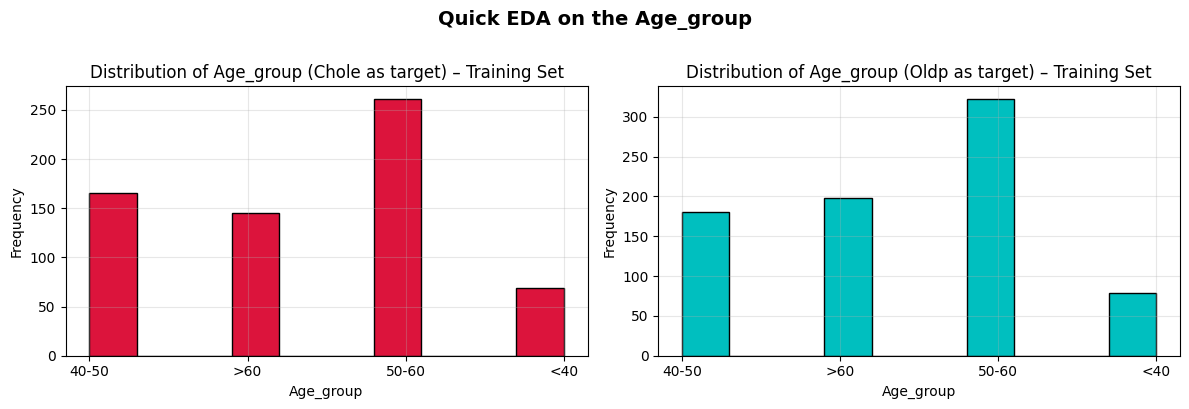

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of RPP (training set)
axes[0].hist(X_CHOLE_TRAIN['Age_group'], color='crimson', edgecolor='k')
axes[0].set_title(f'Distribution of {'Age_group'} (Chole as target) – Training Set')
axes[0].set_xlabel('Age_group')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)


# Histogram of RPP (training set)
axes[1].hist(X_OLDP_TRAIN['Age_group'], color='c', edgecolor='k')
axes[1].set_title(f'Distribution of {'Age_group'} (Oldp as target) – Training Set')
axes[1].set_xlabel('Age_group')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)


plt.suptitle(f"Quick EDA on the {'Age_group'}", fontsize=14, weight='bold' ,y=1.01)
plt.tight_layout()
plt.show()


#### - Analyze correlations after feature engineering

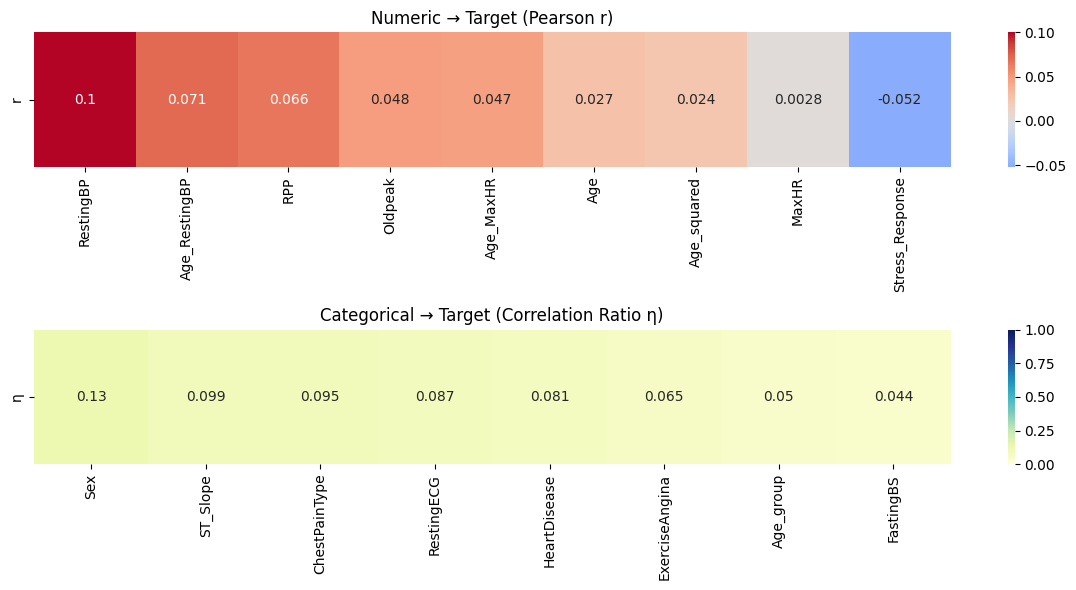

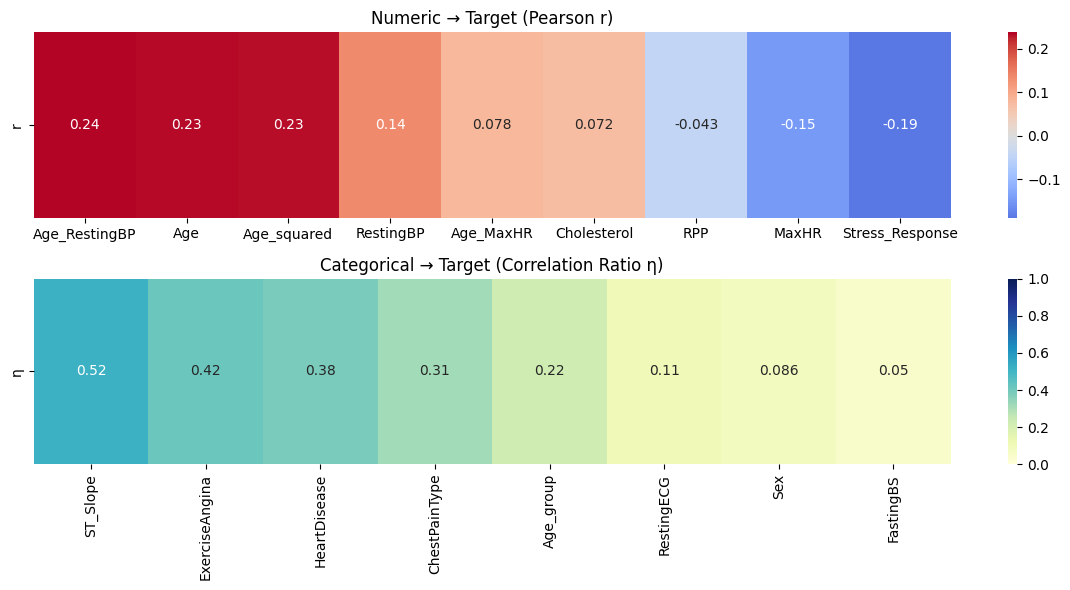

In [11]:
# Analyze correlations after feature eng
#----------------------------------------

# Chole as the target
con_num_features = ['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'RPP',
                    'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']
# Oldp as the target
con_num_features_ = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol', 'RPP',
                    'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']

cat_features = ['Sex', 'ExerciseAngina', 'FastingBS', 'ChestPainType', 'RestingECG',
                 'ST_Slope', 'Age_group', 'HeartDisease']

# Create DataFrames that contain the new engineered features AND the target
full_train_ana_chole = X_CHOLE_TRAIN.copy()
full_train_ana_chole['Cholesterol'] = y_chole_train.values

full_train_ana_oldp = X_OLDP_TRAIN.copy()
full_train_ana_oldp['Oldpeak'] = y_oldp_train.values

# Now pass them to the analyzer
analyzer_ch = CorrelationAnalyzer(
    data=full_train_ana_chole,
    target_type='numeric',
    num_cols=con_num_features,
    cat_cols=cat_features,
    target_col='Cholesterol'
)

analyzer_ol = CorrelationAnalyzer(
    data=full_train_ana_oldp,
    target_type='numeric',
    num_cols=con_num_features_,
    cat_cols=cat_features,
    target_col='Oldpeak'
)

analyzer_ch.plot_feature_numeric_target()
analyzer_ol.plot_feature_numeric_target()

### Validation strategy for regression

In the classification task we used a **train/validation** split to compare models and tune the threshold,
and a separate **held‑out test set** for final evaluation.

For regression, we take a more robust approach that is especially suitable when the dataset is small:

- The **same held‑out test set** (created in the EDA phase) is kept untouched for the final evaluation.
- On the **training set only**, we use **k‑fold cross‑validation** (k=5) to estimate the performance
  of each regression model.  
  This removes the randomness of a single train/validation split and gives a more stable ranking
  of the models.
- The final model is then **retrained on the entire training set** and evaluated **once** on the
  test set – exactly like in the classification workflow.

This is a standard and respected practice in machine learning, especially with limited data.
It ensures that all model selection decisions are made without ever seeing the test set.

### 6) Core of preprocessing and handling data


##### 1 - Cleanup Operations

In [8]:
"""
Two continuous numeric features were spotted having INVALID,
 IMPOSSIBLE vlues BIOLOGICLY & in terms of MEDICAL SCIENCE
 * RestingBP -> 1 case with the value 0 (since it's only one case it's better to be removed)
 * OldPeak -> 13 cases with negative values (there are atleast two ways to consider)
    - Replacing negative values with the baseline which is 0 (clipping)
    - Using median imputation
    -> First option is reasonable since number of cases is low
"""

#---------------------------------------------------------------------------------------
# - RestingBP invalid values handling: 
#   Because this part will change the number of rows and values 
#   of the target col SO we need to implement it outside Pipeline 
#   to not run into any problem (This cell)

# - OldPeak invalid values handling: 
#   OldPeak gets filtered and negative values will be replaced with zero,
#   so that they all will be preprocessed consistently inside pipeline (Next cells)
#----------------------------------------------------------------------------------------

# -----RestingBP-----

# -------------------------------------
# Cholesterol as the target
# -------------------------------------

#  Data
#--------------
X_CHOLE_TRAIN, y_chole_train = drop_invalid_resting_bp(X_CHOLE_TRAIN, y_chole_train)

# Test
#---------------
X_CHOLE_TEST, y_chole_test = drop_invalid_resting_bp(X_CHOLE_TEST, y_chole_test)


# -------------------------------------
# Oldpeak as the target
# -------------------------------------

#  Data
#--------------
X_OLDP_TRAIN, y_oldp_train = drop_invalid_resting_bp(X_OLDP_TRAIN, y_oldp_train)

# Test
#---------------
X_OLDP_TEST, y_oldp_test = drop_invalid_resting_bp(X_OLDP_TEST, y_oldp_test)



print("-----Done-----")

-----Done-----


##### 2 - Check Outliers & Skewness
Checking outliers and skewness after cleanup operations

In [13]:
ch = X_CHOLE_TRAIN[con_num_features]

# Check outliers of X_WOUT_HD_DATA after cleanup operation to decide which scaler to use
df_out = outlier_detector(ch)

# Check skewness of X_WOUT_HD_DATA after cleanup operation
df_sk  = skewness_detector(ch)

# Combine into one overview DataFrame
df_summary = pd.concat([df_out, df_sk], axis=1).reset_index(drop=True)
keep = [0,1,2,4,5]

print("Outlier & Skewness Summary (before scaling):")
df_summary.iloc[:, keep] # Drop the second `Feature` column in df


Outlier & Skewness Summary (before scaling):


,Feature,N_outliers,Outlier_pct,Skewness,Skewness_Exceeding_Threshold
0,RestingBP,16,2.496,1.140801,True
1,Oldpeak,12,1.872,0.622707,False
2,RPP,6,0.936,0.330310,False
3,Stress_Response,3,0.468,0.300655,False
4,Age_RestingBP,3,0.468,0.271493,False
5,Age_squared,2,0.312,0.253107,False
6,Age_MaxHR,1,0.156,0.187046,False
7,Age,0,0.000,0.180959,False
8,MaxHR,0,0.000,0.118635,False


In [14]:
ol = X_OLDP_TRAIN[con_num_features_]

# Check outliers of X_WOUT_HD_DATA after cleanup operation to decide which scaler to use
df_out = outlier_detector(ol)

# Check skewness of X_WOUT_HD_DATA after cleanup operation
df_sk  = skewness_detector(ol)

# Combine into one overview DataFrame
df_summary = pd.concat([df_out, df_sk], axis=1).reset_index(drop=True)
keep = [0,1,2,4,5]

print("Outlier & Skewness Summary (before scaling):")
df_summary.iloc[:, keep] # Drop the second `Feature` column in df


Outlier & Skewness Summary (before scaling):


,Feature,N_outliers,Outlier_pct,Skewness,Skewness_Exceeding_Threshold
0,Cholesterol,149,19.127,0.617980,False
1,RestingBP,23,2.953,0.607026,False
2,RPP,5,0.642,0.309940,False
3,Age_RestingBP,5,0.642,0.261967,False
4,Stress_Response,2,0.257,0.233348,False
5,Age_MaxHR,1,0.128,0.218176,False
6,MaxHR,1,0.128,0.192367,False
7,Age,0,0.000,0.174821,False
8,Age_squared,0,0.000,0.163001,False


#### 3 - The full preprocessing pipeline

In [9]:
"""
Preprocessing Pipelines for Heart Disease Data (Two Targets)

Continuous numeric features are imputed with median and scaled using StandardScaler.
* Features for Cholesterol target: 
  ['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'RPP', 'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']
* Features for Oldpeak target:
  ['Age', 'RestingBP', 'MaxHR', 'Cholesterol', 'RPP', 'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']

Categorical features are split into three groups:
1. Binary features (imputed with most_frequent, then OrdinalEncoder):
   ['Sex', 'ExerciseAngina', 'FastingBS', 'HeartDisease']
2. Nominal features (imputed with most_frequent, then OneHotEncoder with sparse=False, handle_unknown='ignore'):
   ['ChestPainType', 'RestingECG', 'Age_group']
3. Ordinal feature (imputed with most_frequent, then OrdinalEncoder with explicit categories order ['Down','Flat','Up']):
   ['ST_Slope']

A ColumnTransformer combines all pipelines, dropping any remaining columns.
Two full preprocessing pipelines are created (using a custom MedicalColumnCleaner):
- `full_preprocessor_ch` for Cholesterol target (cleans Oldpeak column, ignores Cholesterol)
- `full_preprocessor_ol` for Oldpeak target (cleans Cholesterol column, ignores Oldpeak)

All pipelines are built using scikit-learn's Pipeline and ColumnTransformer.
"""

# Identify columns
#------------------

#----- Continuous numeric features -----


# Chole as the target
con_num_features = ['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'RPP', 'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']
# Oldp as the target
con_num_features_ = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol', 'RPP', 'Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response']

# Categorical features
bin_features = ['Sex', 'ExerciseAngina', 'FastingBS', 'HeartDisease']
nom_features = ['ChestPainType', 'RestingECG', 'Age_group']
ord_features = ['ST_Slope']


# Continuos numeric Pipelines
#------------------------------

# Continuous numeric Pipeline 
con_num_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Pipelines
#------------------------------

# Binary features Pipeline
bin_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder())
])

# Nominal features Pipeline
nom_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe_encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Ordinal features Pipeline
ord_Pipeline = Pipeline(([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]))
]))


# Combine all Pipelines to build the full preprocessor
#------------------------------------------------------

#-----  Cholesterol as the target -----

# The column transformer to perform feature engineering
preprocessor_ch = ColumnTransformer([
    ("con_num", con_num_Pipeline, con_num_features),
    ("bin", bin_Pipeline, bin_features),
    ("nom", nom_Pipeline, nom_features),
    ("ord", ord_Pipeline, ord_features)
], remainder="drop")

# Full preprocessing pipeline: clean columns first, then feature engineering
full_preprocessor_ch = Pipeline([
    ("clean_columns", MedicalColumnCleaner(oldpeak_col='Oldpeak', cholesterol_col=None)),
    ("feature_engineering", preprocessor_ch)
])


#-----  Oldpeak as the target -----

# The column transformer to perform feature engineering
preprocessor_ol = ColumnTransformer([
    ("con_num", con_num_Pipeline, con_num_features_),
    ("bin", bin_Pipeline, bin_features),
    ("nom", nom_Pipeline, nom_features),
    ("ord", ord_Pipeline, ord_features)
], remainder="drop")

# Full preprocessing pipeline: clean columns first, then feature engineering
full_preprocessor_ol = Pipeline([
    ("clean_columns", MedicalColumnCleaner(oldpeak_col=None, cholesterol_col='Cholesterol')),
    ("feature_engineering", preprocessor_ol)
])

print("-----Preprocessing with pipelines done-----")


-----Preprocessing with pipelines done-----


####  - Fit on the full training data and transform  

In [11]:
# Cholesterol as the target
#-----------------------------

# Fit on the entire training set 
full_preprocessor_ch.fit(X_CHOLE_TRAIN)

# Transform both training and test sets
X_train_prep_ch = full_preprocessor_ch.transform(X_CHOLE_TRAIN).astype(np.float32)
X_test_prep_ch  = full_preprocessor_ch.transform(X_CHOLE_TEST).astype(np.float32)

# Targets
y_train_ch = y_chole_train.values   # from earlier split
y_test_ch  = y_chole_test.values

print("X_train_prep shape:", X_train_prep_ch.shape)
print("X_test_prep shape:",  X_test_prep_ch.shape)

X_train_prep shape: (641, 25)
X_test_prep shape: (105, 25)


In [10]:
# Oldpeak as the target
#-----------------------------

# Fit on the entire training set 
full_preprocessor_ol.fit(X_OLDP_TRAIN)

# Transform both training and test sets
X_train_prep_ol = full_preprocessor_ol.transform(X_OLDP_TRAIN).astype(np.float32)
X_test_prep_ol  = full_preprocessor_ol.transform(X_OLDP_TEST).astype(np.float32)

# Targets
y_train_ol = y_oldp_train.values   # from earlier split
y_test_ol  = y_oldp_test.values

print("X_train_prep shape:", X_train_prep_ol.shape)
print("X_test_prep shape:",  X_test_prep_ol.shape)

X_train_prep shape: (779, 25)
X_test_prep shape: (138, 25)


### 10) Model Benchmarking 

In [ ]:
# Initialize the models
models = {
    'AdaBoost Regressor': AdaBoostRegressor(),
    'Extra Trees Regressor': ExtraTreesRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Elastic Net': ElasticNet(),
    'RANSAC Regressor': RANSACRegressor(),
    'Huber Regressor': HuberRegressor(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'Linear Regression': LinearRegression(),
    'SVR': SVR(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Gaussian Process Regressor': GaussianProcessRegressor(),
    'K-Neighbors Regressor': KNeighborsRegressor()
}


# Scoring metrics: we'll compute RMSE manually from neg_mean_squared_error, and use r2 directly
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error'
}
# If 'neg_root_mean_squared_error' is not available (older sklearn), use 'neg_mean_squared_error' and convert manually.


def model_benchmark(models, X, y, scoring):
    # Cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results = []

    for name, model in models.items():
        regressor = clone(model)

        # cross_validate
        cv_results = cross_validate(
            regressor, X, y,
            cv=cv, scoring=scoring,
            return_train_score=False, n_jobs=-1
        )
        
        # Extract mean and std of each metric
        # If using neg_root_mean_squared_error:
        rmse_mean = -cv_results['test_RMSE'].mean()
        rmse_std  =  cv_results['test_RMSE'].std()
        r2_mean   =  cv_results['test_R2'].mean()
        r2_std    =  cv_results['test_R2'].std()
        mae_mean  = -cv_results['test_MAE'].mean()
        mae_std   =  cv_results['test_MAE'].std()
        
        results.append({
            "Model": name,
            "R2_mean": r2_mean,
            "R2_std": r2_std,
            "RMSE_mean": rmse_mean,
            "RMSE_std": rmse_std,
            "MAE_mean": mae_mean, 
            "MAE_std": mae_std
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    # Sort by R² descending
    results_df = results_df.sort_values(by='R2_mean', ascending=False).reset_index(drop=True)
    return results_df


# Without HD
results_chole = model_benchmark(models, X_train_prep_ch, y_train_ch, scoring)

# With HD
results_oldp = model_benchmark(models, X_train_prep_ol, y_train_ol, scoring)


print('----- Benchmarking results saved -----')

#### - Results of models on Cholesterol

In [19]:
results_chole

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Elastic Net,0.001827,0.014748,59.838371,4.670773,44.108179,1.677964
1,Lasso,0.000701,0.027252,59.892699,5.014824,44.144984,1.893235
2,Huber Regressor,-0.014651,0.065749,60.313055,5.194043,43.827315,2.336540
3,Ridge,-0.015717,0.047366,60.371986,5.185120,44.392376,2.213327
4,SVR,-0.018235,0.031553,60.401166,4.401939,44.016288,1.691522
5,Linear Regression,-0.021443,0.051117,60.536375,5.190681,44.536868,2.300188
6,Gradient Boosting Regressor,-0.065506,0.064500,61.702345,3.858757,45.856794,1.416547
7,Random Forest Regressor,-0.079522,0.074865,62.103601,4.155639,45.598254,0.930693
8,AdaBoost Regressor,-0.124883,0.100108,63.354178,4.535498,46.705546,0.992624
9,K-Neighbors Regressor,-0.136839,0.107312,63.664872,4.420103,46.970533,1.863447


#### - Results of models on Oldpeak

In [20]:
results_oldp

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Ridge,0.307077,0.071049,0.874881,0.078516,0.642399,0.047629
1,Linear Regression,0.302293,0.072682,0.877866,0.079304,0.645112,0.048789
2,Huber Regressor,0.300462,0.066772,0.879168,0.077047,0.632290,0.045812
3,Gradient Boosting Regressor,0.298094,0.093588,0.879021,0.080502,0.650385,0.043577
4,SVR,0.264805,0.066057,0.901006,0.073080,0.637871,0.040738
5,Random Forest Regressor,0.257531,0.071369,0.903871,0.057194,0.658519,0.027240
6,AdaBoost Regressor,0.181281,0.066167,0.949582,0.054021,0.787847,0.036695
7,Extra Trees Regressor,0.115865,0.067614,0.987997,0.073963,0.692864,0.040710
8,K-Neighbors Regressor,0.115561,0.112229,0.986253,0.080116,0.719516,0.060651
9,Elastic Net,-0.003440,0.003084,1.053099,0.062634,0.876059,0.050969


#### - The results of benchmarking visualized

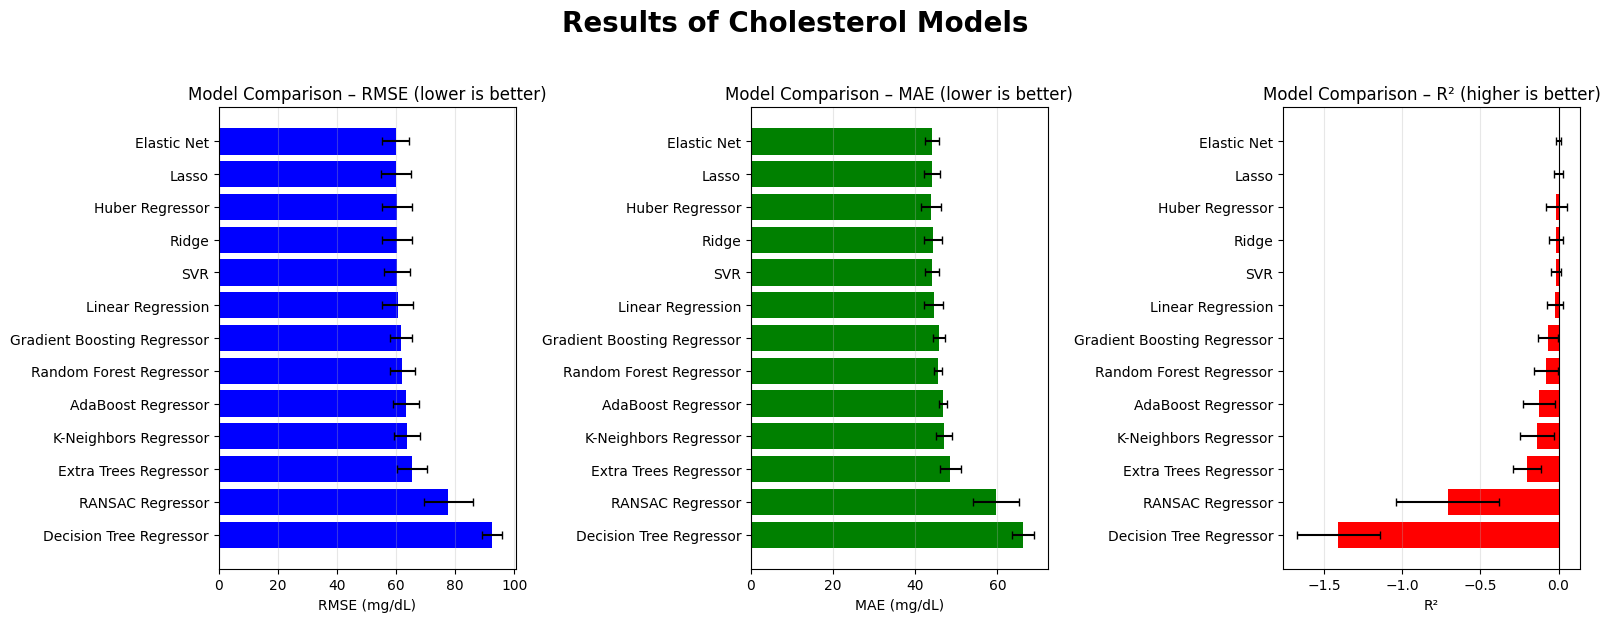

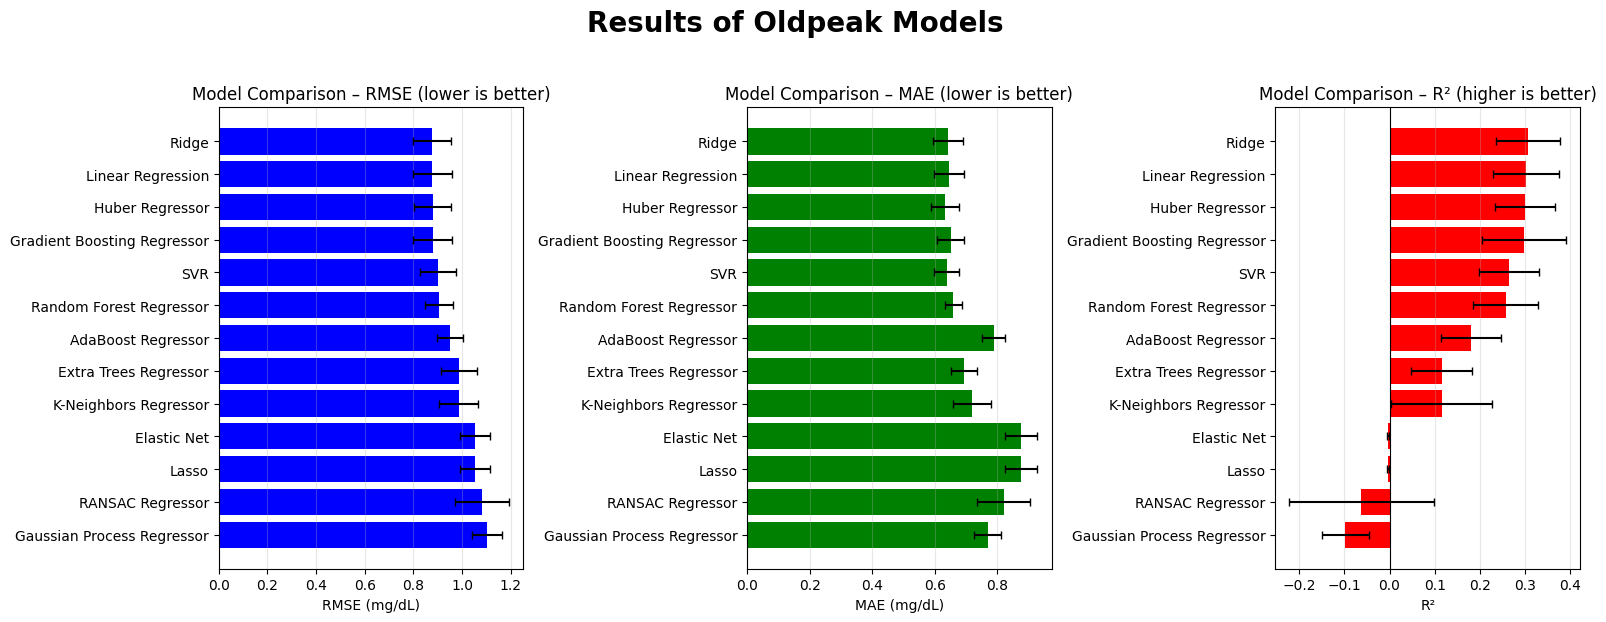

In [21]:
def plot_benchmarking_results(df, m):
    # Drop the Gaussian Process row for plotting (or keep it – it will dominate the scale)
    plot_df = df.drop(index=13)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

    # --- RMSE ---
    ax1.barh(plot_df['Model'], plot_df['RMSE_mean'],
            xerr=plot_df['RMSE_std'], color='b', capsize=3)
    ax1.set_xlabel('RMSE (mg/dL)')
    ax1.set_title('Model Comparison – RMSE (lower is better)')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

    # --- MAE ---
    ax2.barh(plot_df['Model'], plot_df['MAE_mean'],
            xerr=plot_df['MAE_std'], color='g', capsize=3)
    ax2.set_xlabel('MAE (mg/dL)')
    ax2.set_title('Model Comparison – MAE (lower is better)')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

    # --- R² ---
    ax3.barh(plot_df['Model'], plot_df['R2_mean'],
            xerr=plot_df['R2_std'], color='r', capsize=3)
    ax3.axvline(0, color='black', linewidth=0.8)
    ax3.set_xlabel('R²')
    ax3.set_title('Model Comparison – R² (higher is better)')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)

    plt.suptitle(f"Results of {m}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


plot_benchmarking_results(results_chole, 'Cholesterol Models')
plot_benchmarking_results(results_oldp, 'Oldpeak Models')

#### -  Predicted‑vs‑actual scatter for top‑3 regressors

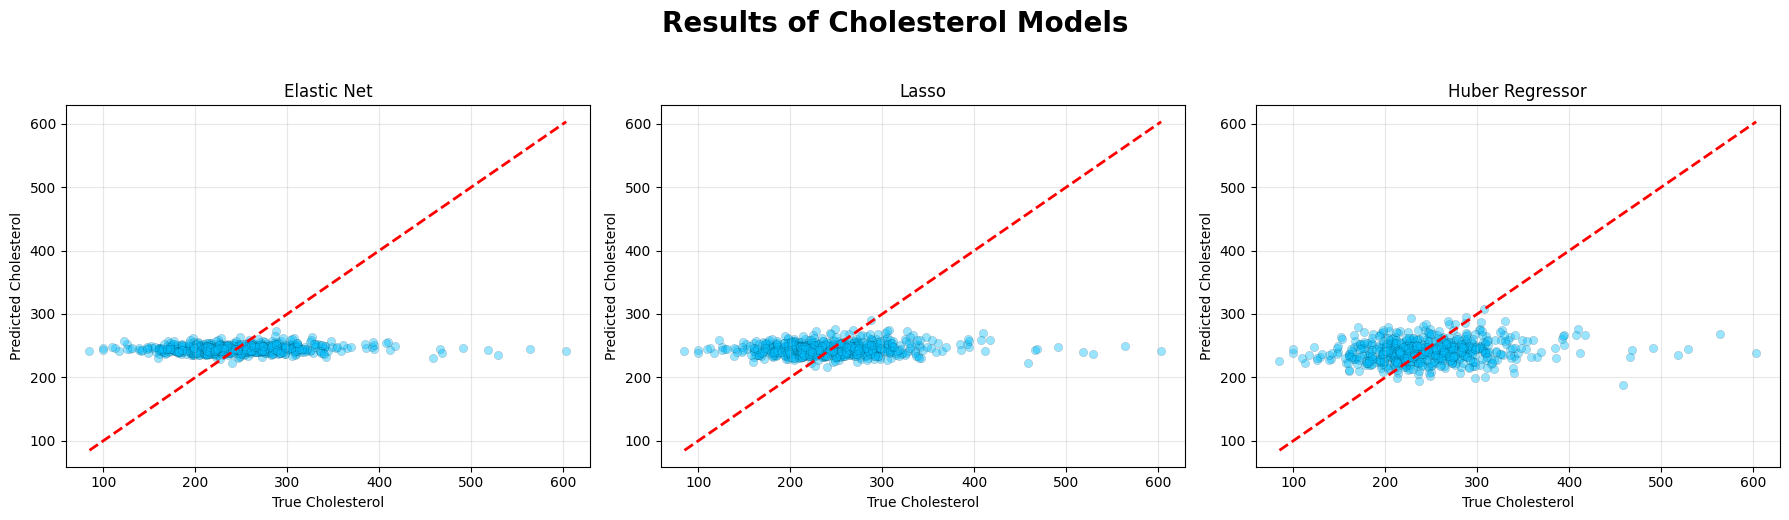

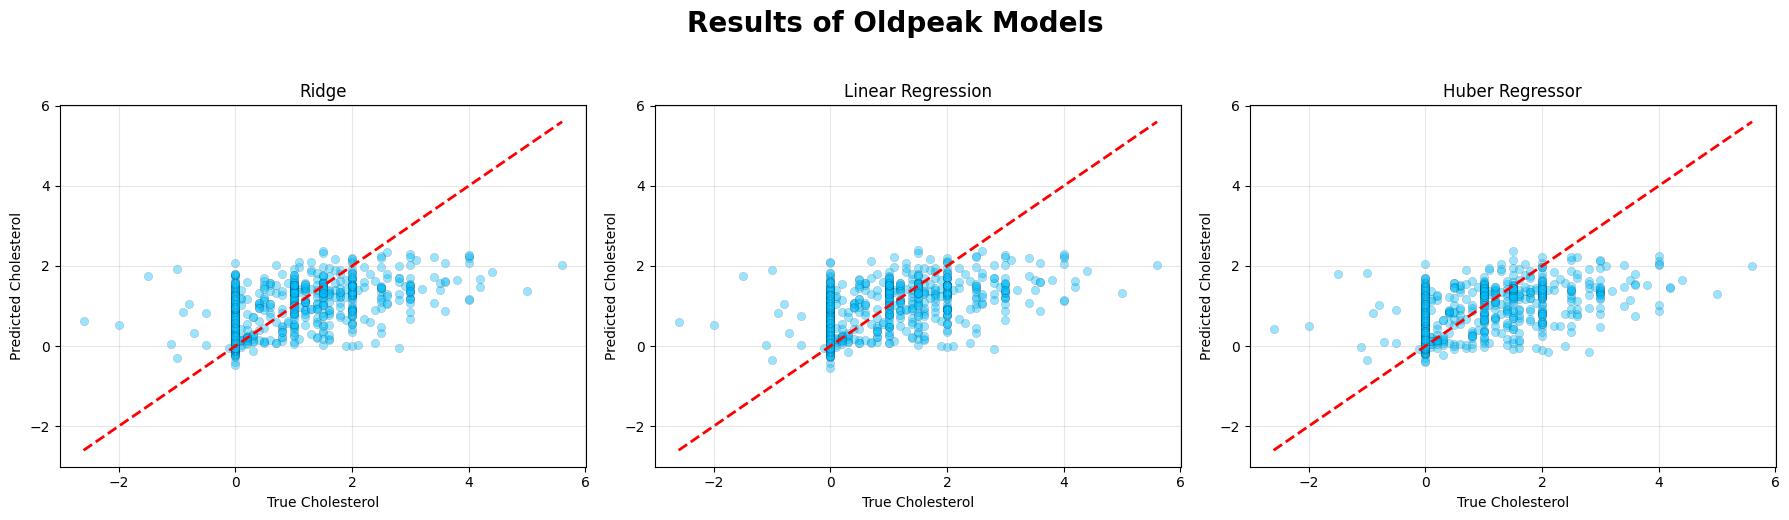

In [22]:
def plot_pred_vs_act(df, X, y, text):
    # Choose top 3 models by R2_mean (from results_df)
    top3_names = df.drop(index=13)['Model'].head(3).tolist()   # skip Gaussian Process
    top3_models = {name: models[name] for name in top3_names}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, model) in zip(axes, top3_models.items()):
        reg = clone(model)
        y_cv_pred = cross_val_predict(reg, X, y,
                                    cv=5, n_jobs=-1)
        ax.scatter(y, y_cv_pred, alpha=0.4, edgecolors='k', color='deepskyblue', linewidth=0.2)
        ax.plot([y.min(), y.max()],
                [y.min(), y.max()], 'r--', lw=2)
        ax.set_xlabel('True Cholesterol')
        ax.set_ylabel('Predicted Cholesterol')
        ax.set_title(name)
        ax.grid(alpha=0.3)

    plt.suptitle(f"Results of {text}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


plot_pred_vs_act(results_chole, X_train_prep_ch, y_train_ch, 'Cholesterol Models')
plot_pred_vs_act(results_oldp, X_train_prep_ol, y_train_ol, 'Oldpeak Models')

### 11) FE Benchmark
Check the best engineered features for Oldpeak

In [23]:

# Baseline feature lists
base_con_num = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol']
base_cat = ['Sex', 'ExerciseAngina', 'FastingBS', 'ChestPainType', 'RestingECG', 'ST_Slope', 'HeartDisease']

# Candidate engineered features to test
candidates = ['Age_MaxHR', 'Age_RestingBP', 'Age_squared', 'Stress_Response', 'RPP']

# Base Model
MODEL = Ridge()

# Store results
fe_results = []

# --- Helper to build a preprocessor given numeric columns ---
def make_preprocessor(con_features, cat_features):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    col_trans = ColumnTransformer([
        ("num", num_pipe, con_features),
        ("cat", cat_pipe, cat_features)
    ], remainder="drop")
    return Pipeline([
        ("clean", MedicalColumnCleaner(oldpeak_col=None, cholesterol_col='Cholesterol')),
        ("feat_eng", col_trans)
    ])

# --- Baseline ---
prep_base = make_preprocessor(base_con_num, base_cat)
pipe_base = Pipeline([("prep", prep_base), ("model", MODEL)])
r2_base = cross_val_score(pipe_base, X_OLDP_TRAIN, y_oldp_train,
                          cv=5, scoring='r2').mean()
fe_results.append({"Feature": "Baseline (none)", "R2_mean": r2_base})

# --- Test each candidate ---
for feat in candidates:
    test_con = base_con_num + [feat]
    prep_test = make_preprocessor(test_con, base_cat)
    pipe_test = Pipeline([("prep", prep_test), ("model", MODEL)])
    r2_test = cross_val_score(pipe_test, X_OLDP_TRAIN, y_oldp_train,
                              cv=5, scoring='r2').mean()
    fe_results.append({"Feature": feat, "R2_mean": r2_test})

fe_results_df = pd.DataFrame(fe_results).sort_values(by='R2_mean', ascending=False)
fe_results_df

,Feature,R2_mean
1,Age_MaxHR,0.318234
5,RPP,0.317967
2,Age_RestingBP,0.317790
0,Baseline (none),0.317526
4,Stress_Response,0.317522
3,Age_squared,0.316252


### 12) The final training on the full train set 
> The best candidate compared to others - Ridge for Oldpeak/ElasticNet for Cholesterol

##### - Cholesterol:

In [24]:
# fit-transform, and preprocessing have been done before
final_ch_model = ElasticNet() # default hyperparameters
final_ch_model.fit(X_train_prep_ch, y_train_ch)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


##### - Olspeak:

In [13]:
# fit-transform, and preprocessing have been done before
final_ol_model = Ridge() # default hyperparameters
final_ol_model.fit(X_train_prep_ol, y_train_ol)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 13) The final evaluation on the test set

#### - Fundamental evaluation metrics

##### - Cholesterol:

In [26]:
# Predict on the test set
y_pred_ch = final_ch_model.predict(X_test_prep_ch)

# Compute evaluation metrics (RMSE - MAE - R²)
rmse = np.sqrt(mean_squared_error(y_test_ch, y_pred_ch))
mae = mean_absolute_error(y_test_ch, y_pred_ch)
r2 = r2_score(y_test_ch, y_pred_ch)

print(f"Test set performance (Cholesterol model - ElasticNet):")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"R²:   {r2:.4f}")

Test set performance (Cholesterol model - ElasticNet):
RMSE: 51.75 mg/dL
MAE:  41.14 mg/dL
R²:   0.0096


##### - Oldpeak:

In [14]:
# Predict on the test set
y_pred_ol = final_ol_model.predict(X_test_prep_ol)

# Compute evaluation metrics (RMSE - MAE - R²)
rmse = np.sqrt(mean_squared_error(y_test_ol, y_pred_ol))
mae = mean_absolute_error(y_test_ol, y_pred_ol)
r2 = r2_score(y_test_ol, y_pred_ol)

print(f"Test set performance (Oldpeak codel - Ridge):")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"R²:   {r2:.4f}")

Test set performance (Oldpeak codel - Ridge):
RMSE: 0.94 mg/dL
MAE:  0.65 mg/dL
R²:   0.3040


#### -  Plot predicted vs actual (test set)

##### - Cholesterol:

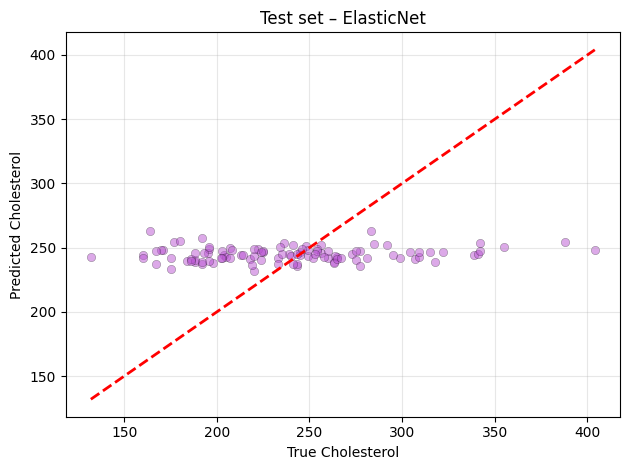

In [28]:
# Plot
plt.scatter(y_test_ch, y_pred_ch, alpha=0.5, edgecolors='k', color='mediumorchid', linewidth=0.3)
plt.plot([y_test_ch.min(), y_test_ch.max()], [y_test_ch.min(), y_test_ch.max()], 'r--', lw=2)
plt.xlabel('True Cholesterol')
plt.ylabel('Predicted Cholesterol')
plt.title('Test set – ElasticNet')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### - Oldpeak:

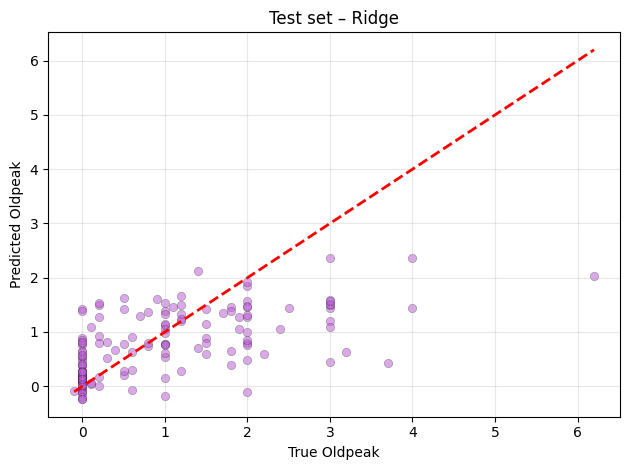

In [29]:
# Plot
plt.scatter(y_test_ol, y_pred_ol, alpha=0.5, edgecolors='k', color='mediumorchid', linewidth=0.3)
plt.plot([y_test_ol.min(), y_test_ol.max()], [y_test_ol.min(), y_test_ol.max()], 'r--', lw=2)
plt.xlabel('True Oldpeak')
plt.ylabel('Predicted Oldpeak')
plt.title('Test set – Ridge')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

joblib.dump(final_ol_model, PROJECT_ROOT / "Models/Regression/Oldpeak_model.joblib")
print("Model Saved: Oldpeak_model.joblib")

Model Saved: Oldpeak_model.joblib


## Conclusion – Regression on the original dataset

In this regression investigation we targeted two continuous variables:

- **Cholesterol** – After rigorous preprocessing and benchmarking, all models
  achieved R² ≈ 0.0 (in cross‑validation and on the held‑out test set). The
  available clinical features contain no detectable signal for predicting
  cholesterol. This negative result demonstrates the framework’s ability to
  reveal when a target is not predictable from the data at hand, preventing
  deployment of a useless model.

- **Oldpeak** – The same pipeline produced a moderately useful model, with
  Ridge regression achieving R² ≈ 0.30 and RMSE ≈ 0.94 on the test set. The
  dominance of linear models over tree‑based ensembles for this target is an
  interesting methodological finding.

- **Feature engineering** – We systematically tested several clinically
  motivated derived features (Age × MaxHR, Age², Stress Response, etc.).
  None raised the cross‑validated R² by more than a fraction of a percent,
  so the simple baseline feature set was retained.

- **HeartDisease status** – Adding the known disease label did not improve
  predictions, indicating that Oldpeak is already sufficiently captured by
  the other clinical predictors.

### Key take‑away

The regression paradigm of the framework successfully:
- Detected an unpredictable target (cholesterol).
- Built a modest but honest predictive model for a predictable target
  (Oldpeak).
- Demonstrated that domain‑driven feature engineering does not always help
  and must be validated with cross‑validation.

In the next step, the framework will be applied to an **external dataset**
(the Framingham Heart Study) to predict cholesterol from a richer set of
lifestyle and clinical features, testing generalizability across data sources
and targets.